## Airbnb Chatbot
Collaborators: Ben Ghouzi, Shawn Lokshin, Khadiatou Ly, Veronica Song

Goal: Build a chatbot that can process user's natural language queries to recommend experiences and services based on user-user filtering and selected housing location

In [1]:
# libraries
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import faiss
import os
import re
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# !python -m spacy download en_core_web_sm

/Users/kadely/anaconda3/envs/airbnb_nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
listings     = pd.read_csv("data/listings.csv")
reviews      = pd.read_csv("data/reviews.csv")
user_booking = pd.read_csv("data/user_bookings.csv")

user_booking.head()

,user_id,listing_id,city,trip_purpose,guests,nights_stayed,total_paid,rating,booking_month
0,U0145,L0290,Chicago,group,4,3,834,5,10
1,U0189,L0337,New York,leisure,2,3,768,4,7
2,U0172,L0016,Boston,leisure,2,7,1197,3,3
3,U0020,L0465,Miami,romantic,2,7,826,5,2
4,U0024,L0148,Boston,leisure,1,5,550,5,12


## Sentiment Analysis

Assigns a sentiment score to each user review

In [3]:
# using clustering text analysis to determine sentiment from user reviews
# goal: assign a numeric rating to each users review from reviews.csv

# Install dependencies if needed:
# pip install pandas spacy nltk vaderSentiment


# Download punkt tokenizer if not already downloaded
nltk.download('punkt')

# Load spaCy English model
# python -m spacy download en_core_web_sm
nlp      = spacy.load("en_core_web_sm")

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# -------------------------------
# 1. Load Data
# -------------------------------

# Ensure the required column exists in the reviews DataFrame
assert "review_text" in reviews.columns

# -------------------------------
# 2. Sentiment Scoring
# -------------------------------

def compute_review_sentiment(text):
    """
    Compute an overall sentiment score for a  review
    """
    str_text = str(text)

    # score the whole review at once
    primary = analyzer.polarity_scores(str_text)['compound']

    # sentence-level average
    doc = nlp(str_text)
    sent_scores = [
        analyzer.polarity_scores(s.text)['compound']
        for s in doc.sents
    ]
    avg_sent = sum(sent_scores) / len(sent_scores) if sent_scores else 0

    # weight full-review score more heavily than sentence average
    final_score = 0.7 * primary + 0.3 * avg_sent

    return final_score, []

# -------------------------------
# 3. Apply to Dataset
# -------------------------------
results = reviews["review_text"].apply(compute_review_sentiment)

reviews["sentiment_score"]  = results.apply(lambda x: x[0])
reviews["phrase_sentiments"] = results.apply(lambda x: x[1])

# -------------------------------
# 4. Label Categories
# -------------------------------

def label_sentiment(score):
    """
    Convert a numeric VADER compound score to a
        'positive', 'negative', or 'neutral' label.
    """
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

reviews["sentiment_label"] = reviews["sentiment_score"].apply(label_sentiment)

# -------------------------------
# 5. Save Results
# -------------------------------
reviews.to_csv("reviews_with_sentiment.csv", index=False)

# -------------------------------
# 6. Preview Example
# -------------------------------
print(reviews[["review_text", "sentiment_score", "sentiment_label"]].head())

[nltk_data] Downloading package punkt to /Users/kadely/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                         review_text  sentiment_score  \
0  Stayed here for a week and loved every minute....          0.71778   
1  Great location, just 9 minutes from Lexington ...          0.71354   
2  Beautiful apartment in a great part of New Yor...          0.67216   
3  Perfect for our business trip. Close to Centra...          0.74377   
4  Wonderful host, beautiful space in Midtown Man...          0.73843   

  sentiment_label  
0        positive  
1        positive  
2        positive  
3        positive  
4        positive  


LLM prompt used: Act like a professional data scientist. I am currently trying to build a sentiment text analysis model based off user review text stored in reviews.csv under column review_text. Please code in python a phrase-level sentiment analyser that separates out the user reviews into phrases and then assigns an overall user sentiment score to their review.

# User-user Collaborative Filtering

In [4]:
# Setting up user-user collaborative filtering.
# Build a user-user cosine similarity matrix from ratings

# The chatbot uses this matrix to find users who booked and rated listings similarly to the target user, then recommends listings those similar users


# -------------------------------
# 1. Build User-Item Rating Matrix
# -------------------------------
# Rows = users, columns = listings, values = mean star rating (1-5).
ratings_df = user_booking[["user_id", "listing_id", "rating"]]

user_item = ratings_df.pivot_table(
    index="user_id",
    columns="listing_id",
    values="rating",
    # average if a user booked the same listing more than once
    aggfunc="mean"
)

# fallback when a listing has no ratings
global_mean  = ratings_df["rating"].mean()

# mean-centering and prediction
user_means   = user_item.mean(axis=1)
item_means   = user_item.mean(axis=0)

# How many users have rated each listing — used for shrinkage
item_support = user_item.notna().sum(axis=0)

# -------------------------------
# 2. Mean-Center and Fill Missing Values
# -------------------------------
user_item_centered = user_item.sub(user_means, axis=0)
user_item_filled   = user_item_centered.fillna(0)

# -------------------------------
# 3. Compute Cosine Similarity
# -------------------------------
# measures how similarly two users rate the same listings.
user_sim = pd.DataFrame(
    cosine_similarity(user_item_filled),
    index=user_item.index,
    columns=user_item.index
)

# -------------------------------
# 4. Compute Overlap Matrix
# -------------------------------
# Number of listings rated by BOTH users in each pair.
# Used in predict_user_user() to filter out neighbors with too little overlap.
overlap_matrix = (
    user_item.notna().astype(int)
    .dot(user_item.notna().astype(int).T)
)

# -------------------------------
# 5. Preview
# -------------------------------
print(user_sim.head())

user_id  U0001     U0002     U0003  U0004     U0005    U0006     U0007  \
user_id                                                                  
U0001      1.0  0.000000  0.000000    0.0  0.000000  0.00000  0.000000   
U0002      0.0  1.000000  0.047246    0.0 -0.052973  0.00000  0.000000   
U0003      0.0  0.047246  1.000000    0.0  0.000000  0.00000  0.000000   
U0004      0.0  0.000000  0.000000    1.0  0.000000 -0.02849  0.119183   
U0005      0.0 -0.052973  0.000000    0.0  1.000000  0.00000  0.000000   

user_id    U0008  U0009  U0010  ...     U0241  U0242     U0243  U0244  U0245  \
user_id                         ...                                            
U0001    0.00000    0.0    0.0  ... -0.008066    0.0  0.000000    0.0    0.0   
U0002    0.00000    0.0    0.0  ...  0.000000    0.0  0.000000    0.0    0.0   
U0003    0.00000    0.0    0.0  ...  0.000000    0.0  0.000000    0.0    0.0   
U0004    0.00000    0.0    0.0  ...  0.000000    0.0  0.000000    0.0    0.0   
U

LLM prompt used: Act like a professional data scientist. I have a csv file called "reviews_with_sentiment.csv" that has "review_id,listing_id,user_id,review_text,sentiment_score,phrase_sentiments,sentiment_label". Based on the sentiment_score and user_id, please build out another csv file that has the cosine similarity score for user-user based collaborative filtering. 

In [5]:
def get_shrunk_item_mean(lid, alpha=10):
    """
    Return a shrinkage-adjusted mean rating for a listing.
    """
    if lid not in item_means.index:
        return global_mean
    m = item_means[lid]
    n = item_support[lid]
    if pd.isna(m):
        return global_mean
    return (n * m + alpha * global_mean) / (n + alpha)


def predict_user_user(user, item, k=10):
    """
    Predict how a user would rate an unseen listing using user-user CF.
    """
    # If user or item not in matrix, fall back to shrunk item mean
    if user not in user_item.index or item not in user_item.columns:
        val = get_shrunk_item_mean(item)
        return val, val, 0, 0

    # If user has already rated this item, return the actual rating
    if not pd.isna(user_item.loc[user, item]):
        val = user_item.loc[user, item]
        return val, val, 999, 1

    user_mean = user_means[user] if not pd.isna(user_means[user]) else global_mean

    # Find other users who rated this item with positive similarity
    neighbors = []
    for other in user_item.index:
        if other == user:
            continue
        if pd.isna(user_item.loc[other, item]):
            continue

        sim     = user_sim.loc[user, other]
        overlap = overlap_matrix.loc[user, other]

        # Only use neighbors with positive similarity and at least 1 shared rating
        if sim > 0 and overlap >= 1:
            neighbors.append((other, sim))

    if not neighbors:
        # No usable neighbors, fall back to shrunk item mean
        val = get_shrunk_item_mean(item)
        return val, val, 0, 0

    # Keep only the top-k most similar neighbors
    neighbors = sorted(neighbors, key=lambda x: x[1], reverse=True)[:k]

    # Mean-centered weighted sum
    num, den = 0, 0
    for neighbor, sim in neighbors:
        r = user_item.loc[neighbor, item]
        m = user_means[neighbor] if not pd.isna(user_means[neighbor]) else global_mean
        num += sim * (r - m)
        den += abs(sim)

    # Adjust target user's mean by the weighted average deviation
    adj  = num / den if den else 0
    raw  = user_mean + adj
    pred = float(np.clip(raw, 1, 5))   # clip to valid rating range

    return pred, raw, len(neighbors), min(1, den)

In [6]:
def recommend_from_similar_users(user_id, top_k_users=10, top_n_listings=5):
    """
    Recommend listings for a user via user-user collaborative filtering.
    """
    if user_id not in user_item.index:
        # User has no booking history so there is no CF done
        return []

    #  exclude from recommendations that have already been rated by user
    seen = set(user_item.loc[user_id].dropna().index)

    scores = {}
    for lid in user_item.columns:
        if lid in seen:
            continue

        pred, raw, support, conf = predict_user_user(user_id, lid, k=top_k_users)

        # Final score breakdown:
        #   70% predicted rating
        #   20% prediction confidence
        #   10% listing popularity
        rank = (
            0.7 * raw
            + 0.2 * conf
            + 0.1 * np.log1p(item_support.get(lid, 0))
        )
        scores[lid] = rank

    # rank by score and top listings
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [lid for lid, _ in ranked[:top_n_listings]]

print(recommend_from_similar_users("U0001"))

['L0384', 'L0103', 'L0348', 'L0342', 'L0404']


## Airbnb Chatbot 

Aggregates all the databases together, takes in basic user queries/ questions and generates a recommendation on a place to stay and all relevant details

In [7]:
# load and aggregate all the data
reviews = pd.read_csv("reviews_with_sentiment.csv")

# -------------------------------
# Aggregate review insights
# -------------------------------
#  average sentiment score and the most common sentiment label per listing
review_agg = reviews.groupby("listing_id").agg({
    "sentiment_score": "mean",
    "sentiment_label": lambda x: x.value_counts().idxmax()
}).reset_index()

# -------------------------------
# Aggregate booking insights
# -------------------------------
#  average star rating and the most common trip purpose per listing
booking_agg = user_booking.groupby("listing_id").agg({
    "rating":       "mean",
    "trip_purpose": lambda x: x.value_counts().idxmax()
}).reset_index()

# -------------------------------
# Merge everything
# -------------------------------
# Left-join so every listing is preserved even if it has no reviews/bookings
df = listings.merge(review_agg, on="listing_id", how="left")
df = df.merge(booking_agg,  on="listing_id", how="left")

In [8]:
# Reset index and store integer positions so we can slice doc_embeddings
df = df.reset_index(drop=True)
df['_pos'] = df.index

def create_document(row):
    """
    Serialise a single listing row into a plain-text document string.
    """
    return (
        f"Listing ID: {row['listing_id']}\n"
        f"Location: {row['city']} — {row['neighborhood']}\n"
        f"Property type: {row['property_type']}\n"
        f"Bedrooms: {row['bedrooms']} | Bathrooms: {row['bathrooms']} | Max guests: {row['max_guests']}\n"
        f"Price per night: ${row['price_per_night']}\n"

        f"Amenities: {row['amenities']}\n"
        f"Superhost: {row['superhost']} | Host rating: {row['host_rating']}\n"

        f"Transit: {row['nearest_transit']} ({row['transit_walk_min']} min walk)\n"

        f"Nearby: {row['nearby_attraction_1']}, {row['nearby_attraction_2']}\n"

        f"Review sentiment: {row.get('sentiment_label', 'unknown')} (score: {float(row.get('sentiment_score', 0)):.2f})\n"

        f"Avg user rating: {row.get('rating', 'N/A')}\n"
        f"Common trip purpose: {row.get('trip_purpose', 'N/A')}\n"
    )

documents = df.apply(create_document, axis=1).tolist()

In [9]:
# ------------------------------------------------
# Constraint parsing and hard-filter retrieval
# ------------------------------------------------

BUSINESS_KEYWORDS = {"business", "work", "conference", "meeting", "corporate", "client"}
SHARED_TYPES      = {"shared room", "hostel", "dorm"}

KNOWN_CITIES = ["New York", "Boston", "Chicago", "San Francisco", "Miami"]
KNOWN_HOODS  = [
    "Fenway", "Back Bay", "South End", "Beacon Hill", "North End",
    "East Village", "Lower East Side", "Midtown Manhattan", "Harlem",
    "Upper West Side", "Chelsea", "SoHo", "Park Slope", "Williamsburg", "Astoria",
    "Lakeview", "Wicker Park", "Pilsen", "Gold Coast", "River North",
    "Marina District", "Mission District",
    "South Beach", "Brickell", "Little Havana",
]

def parse_constraints(query: str) -> dict:
    """
    Extract hard numeric and categorical constraints from a natural-language query.
    """
    q = query.lower()
    c = {
        "max_price":       None,
        "min_bedrooms":    None,
        "max_transit_min": None,
        "city":            None,
        "neighborhood":    None,
        "business_only":   bool(BUSINESS_KEYWORDS & set(q.split())),
    }

    # Price ceiling
    m = re.search(
        r"(?:under|less than|below|max(?:imum)?)\s*\$?(\d+)(?:\s*(?:a\s*night|/night|per night))?",
        query, re.I
    )
    if m:
        c["max_price"] = float(m.group(1))

    # Bedroom count — accepts digits or written-out words (one, two … five)
    m = re.search(r"(\d+|one|two|three|four|five)\s*[-\s]?bed(?:room)?s?", query, re.I)
    if m:
        wmap = {"one": 1, "two": 2, "three": 3, "four": 4, "five": 5}
        raw  = m.group(1).lower()
        c["min_bedrooms"] = wmap[raw] if raw in wmap else int(raw)

    # Transit walk time
    m = re.search(r"(\d+)\s*[-\s]?(?:minute|min)\s*walk", query, re.I)
    if m:
        c["max_transit_min"] = int(m.group(1))

    # first match in KNOWN_CITIES list
    for city in KNOWN_CITIES:
        if city.lower() in q:
            c["city"] = city
            break

    # first match in KNOWN_HOODS list
    for hood in KNOWN_HOODS:
        if hood.lower() in q:
            c["neighborhood"] = hood
            break

    return c

In [10]:
def _filter_df(base_df, c, skip=None):
    """
    Apply hard constraints from c to base_df, optionally skipping some keys.
    """
    skip = skip or []
    out  = base_df.copy()

    if c["max_price"]       is not None and "max_price"       not in skip:
        out = out[out["price_per_night"] <= c["max_price"]]
    if c["min_bedrooms"]    is not None and "min_bedrooms"    not in skip:
        out = out[out["bedrooms"] >= c["min_bedrooms"]]
    if c["max_transit_min"] is not None and "max_transit_min" not in skip:
        out = out[out["transit_walk_min"] <= c["max_transit_min"]]
    if c["city"]            is not None and "city"            not in skip:
        out = out[out["city"].str.lower() == c["city"].lower()]
    if c["neighborhood"]    is not None and "neighborhood"    not in skip:
        out = out[out["neighborhood"].str.lower().str.contains(c["neighborhood"].lower(), na=False)]
    if c["business_only"]   and "business_only" not in skip:
        out = out[~out["property_type"].str.lower().isin(SHARED_TYPES)]

    return out


def retrieve_constrained(query, c, top_k=5):
    """
    Find the top listings that match the user's filters. If no listings pass all filters, relax constraints one at a time until results are found
    """
    RELAX_ORDER  = ["max_transit_min", "min_bedrooms", "max_price", "neighborhood", "city"]
    RELAX_LABELS = {
        "max_transit_min": lambda c: f"transit walk ≤{c['max_transit_min']} min",
        "min_bedrooms":    lambda c: f"{c['min_bedrooms']} bedroom(s)",
        "max_price":       lambda c: f"under ${c['max_price']:.0f}/night",
        "neighborhood":    lambda c: c["neighborhood"],
        "city":            lambda c: c["city"],
    }


    skipped  = []
    eligible = _filter_df(df, c)

    for key in RELAX_ORDER:
        if len(eligible) > 0:
            break
        skipped.append(key)
        eligible = _filter_df(df, c, skip=skipped)

    if len(eligible) == 0:
        eligible = df

    relaxation_note = ""
    if skipped:
        labels = [RELAX_LABELS[k](c) for k in skipped if c.get(k)]
        relaxation_note = (
            f"IMPORTANT: No listing meets all the user's requirements. "
            f"The following were relaxed to find the closest match: {', '.join(labels)}. "
            f"Tell the user this clearly and explain the trade-off."
        )

    # Build a FAISS sub-index over only the eligible listings
    positions      = eligible["_pos"].tolist()
    sub_embeddings = doc_embeddings[positions].astype("float32")

    import faiss as _faiss
    sub_idx = _faiss.IndexFlatIP(sub_embeddings.shape[1])
    sub_idx.add(sub_embeddings)

    # Encode the query with the same normalisation as the documents
    q_emb        = embedder.encode([query], normalize_embeddings=True).astype("float32")
    k            = min(top_k, len(eligible))
    _, local_idx = sub_idx.search(q_emb, k)

    docs = [create_document(eligible.iloc[i]) for i in local_idx[0]]
    return docs, relaxation_note

In [11]:
# -----------------------------------------------
# Embed all listing documents and build the global FAISS index
# -----------------------------------------------

# Load the sentence embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

if os.path.exists("doc_embeddings.npy") and os.path.exists("listings.index"):
    # load pre-built embeddings and index from disk
    doc_embeddings = np.load("doc_embeddings.npy")
    index = faiss.read_index("listings.index")
    print("Loaded embeddings and index from disk.")
else:
    # encode all documents and build index from scratch
    doc_embeddings = embedder.encode(
        documents,
        normalize_embeddings=True,   # required for IndexFlatIP == cosine sim
        show_progress_bar=True
    )

    dimension = doc_embeddings.shape[1]
    index = faiss.IndexFlatIP(dimension)
    index.add(np.array(doc_embeddings))

    # Save to disk
    np.save("doc_embeddings.npy", doc_embeddings)
    faiss.write_index(index, "listings.index")
    print("Built and saved embeddings and index.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6036.83it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded embeddings and index from disk.


In [12]:
def retrieve(query, top_k=5):
    """
    Unconstrained semantic retrieval over all listings.
    """
    query_embedding = embedder.encode([query], normalize_embeddings=True)
    distances, indices = index.search(query_embedding, top_k)
    return [documents[i] for i in indices[0]]

In [13]:
def get_listing_docs(listing_ids):
    """
    Retrieve pre-formatted document strings for a list of listing IDs..
    """
    subset = df[df["listing_id"].isin(listing_ids)]
    return subset.apply(create_document, axis=1).tolist()

In [14]:
# -----------------------------------------------
# Load the  model
# -----------------------------------------------
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto"
)

# Qwen ships a generation_config.json that sets temperature/top_p/top_k.
# When do_sample=False those fields are invalid and Transformers warns.
# Clearing them here silences the warning at the source.
model.generation_config.temperature = None
model.generation_config.top_p       = None
model.generation_config.top_k       = None

Loading weights: 100%|██████████| 338/338 [00:06<00:00, 49.98it/s]
Some parameters are on the meta device because they were offloaded to the disk.


In [31]:
def clean_output(text, docs):
    """
    Strip any lines from the model output to ensure consistent and accurate formatting.
    """
    KEEP = ("Top Pick:", "Why:", "Transit:", "Trade-off:")
    lines = text.strip().split("\n")
    clean = []

    for line in lines:
        line = line.strip()
        if any(line.startswith(k) for k in KEEP):
            if line.startswith("Transit:"):
                line = re.sub(r"\s*[-–]\s.*", "", line)
                line = re.sub(r"\s+via\s+.*", "", line)
            clean.append(line)

    result = "\n".join(clean)
    result = result.replace("**", "")

    #  force nearby in output since it doesn't appear
    if docs:
        m = re.search(r"Nearby:\s*(.+)", docs[0])
        if m:
            result = result.replace("Transit:", f"Nearby: {m.group(1).strip()}\nTransit:")

    return result

In [32]:
def generate_answer(query, docs, c, relaxation_note=""):
    """
    Generate a natural-language listing recommendation grounded strictly
    in the retrieved documents.
    """
    context = "\n\n---\n\n".join(docs)

    # Build a bullet-point summary of the user's detected requirements
    req_lines = []
    if c["neighborhood"]:    req_lines.append(f"Neighbourhood: {c['neighborhood']}")
    if c["city"]:            req_lines.append(f"City: {c['city']}")
    if c["min_bedrooms"]:    req_lines.append(f"Bedrooms: {c['min_bedrooms']}+")
    if c["max_price"]:       req_lines.append(f"Max price: ${c['max_price']:.0f}/night")
    if c["max_transit_min"]: req_lines.append(f"Max transit walk: {c['max_transit_min']} min")
    if c["business_only"]:   req_lines.append("Trip type: business (no shared rooms)")
    requirements = ("User requirements:\n" + "\n".join(f"- {l}" for l in req_lines)) if req_lines else "No hard requirements."
    relax_block  = f"\n\n{relaxation_note}" if relaxation_note else ""

    messages = [
        {
            "role": "system",
            "content": (
                "You are an expert Airbnb travel assistant.\n\n"
                "RULES:\n"
                "1. Use ONLY facts copied verbatim from the listings below. Never invent transit names, distances, attractions, prices, or bedroom counts.\n"
                "2. If a field is not present in the listings, write N/A. Do not infer, guess, or use general knowledge.\n"
                "3. Do NOT use markdown — no asterisks, no bold, no bullet points, no headers. Plain text only.\n"
                "4. Always cite the Listing ID, exact price, bedroom count, transit walk time, and nearby attractions exactly as they appear in the data.\n"
                "5. Trade-off: if the neighbourhood is far from the user's stated purpose (e.g. Brooklyn for a business trip), flag it. If there is genuinely no trade-off, write None.\n"
                "6. If a relaxation note is present, open with one honest sentence about which constraint could not be met.\n"
                "7. Format every reply EXACTLY as:\n"
                "   Top Pick: [ID] in [Neighbourhood]\n"
                "   Why: [price per night, avg rating, sentiment label from data]\n"
                "   Nearby: [attraction 1], [attraction 2]\n"
                "   Transit: [station name] ([X] min walk)\n"
                "   Trade-off: [one honest sentence or None]\n"
                "8. Under 120 words total. Stop immediately after Trade-off."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Query: {query}\n\n"
                f"{requirements}{relax_block}\n\n"
                f"Relevant listings:\n{context}\n\n"
                "Give your recommendation now."
            ),
        },
    ]

    text   = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    in_len = inputs["input_ids"].shape[1]

    # no sampling temperature so the model stays grounded
    outputs = model.generate(
        **inputs,
        max_new_tokens=300,
        do_sample=False,
        repetition_penalty=1.15,
        eos_token_id=tokenizer.eos_token_id,
    )

    raw_output = tokenizer.decode(outputs[0][in_len:], skip_special_tokens=True)

    return clean_output(raw_output, docs)

In [17]:
def extract_user_id(query):
    """
    Extract a user ID token (format: U followed by 4+ digits) from the query.
    """
    m = re.search(r"\bU\d{4,}\b", query, re.I)
    return m.group(0).upper() if m else None


def chat(query, user_id=None):
    """
    Airbnb recommendation chatbot.
    """
    if user_id is None:
        user_id = extract_user_id(query)

    c = parse_constraints(query)

    if user_id:
        cf_listings = recommend_from_similar_users(user_id)
        cf_docs     = get_listing_docs(cf_listings)

        # get semantically relevant constraint-filtered listings
        rag_docs, relaxation_note = retrieve_constrained(query, c, top_k=3)

        # merge CF results first so personalized picks are prioritized
        combined = cf_docs + rag_docs
    else:
        # fall back to pure RAG
        combined, relaxation_note = retrieve_constrained(query, c, top_k=5)

    seen, unique = set(), []
    for d in combined:
        if d.strip() not in seen:
            seen.add(d.strip())
            unique.append(d)

    return generate_answer(query, unique[:8], c, relaxation_note)

In [33]:
# Testing chatbot with a basic user query
query = "I am planning a business trip in New York. What is the best place to stay and attractions nearby?"

response = chat(query)
print(response)

Top Pick: L0003 in Park Slope
Why: The property offers excellent amenities like pool, BBQ grill, kitchen, Wi-Fi, heating, and pet-friendly features at a reasonable price ($210/night). It has a high average rating (4.0) and positive review sentiment (score: 0.69).
Nearby: Central Park, Museum of Modern Art
Transit: 14th St-Union Sq (8 min walk)
Trade-off: While this listing fits well within the criteria for a business trip due to its proximity to popular tourist destinations, it does not offer any additional workspace or gym facilities that might be necessary during work hours. However, given the location, these amenities can easily be arranged upon arrival.


In [34]:
# Testing another basic query
query2 = "I am user U0001, please recommend me places to stay based on other users like me"

response2 = chat(query2, user_id="U0001")
print(response2)

Top Pick: L0103 in Chicago — Old Town
Why: The property offers two bedrooms at $189/night, making it affordable while still providing ample space for up to four people. It has amenities such as a hot tub that can cater to various needs during a visit. Near by attractions include Wrigley Field and the Art Institute of Chicago, offering both entertainment and cultural experiences close to home.
Nearby: Wrigley Field, Art Institute of Chicago
Transit: Fullerton L station takes approximately 17 minutes
Trade-off: While this location aligns well with my common trip purposes including leisure, it may have some inconvenience due to its proximity to busy areas like Wrigley Field and the Art Institute of Chicago, potentially affecting quietness levels compared to more residential neighborhoods further away. However, given the high amenity level and convenient location within the city center, these factors do not significantly impact the overall appeal.


In [35]:
# Testing another basic query
query3 = "I want a two-bedroom in Fenway that is a 5 minute walk away from transit and under $300 a night"

response3 = chat(query3)
print(response3)

Top Pick: L0249 in Fenway-Kenmore
Why: $291/night, average rating of 3.0, positive review sentiment (score: 0.41). Near attractions include Newbury Street and Harvard Yard.
Nearby: Harvard Yard, Freedom Trail
Transit: 7 minutes by walking distance to Downtown Crossing.
Trade-off: This listing does not meet the requirement of being within 5-minute walk due to its proximity to Downtown Crossing instead of Copley Square. However, it offers excellent amenities like gym access and free parking, making it suitable for those seeking a more active lifestyle while still staying comfortably close to their destination.


LLM prompt used: Act like a professional software engineer. I am currently trying to build out a basic RAG chatbot that takes in files listings.csv, reviews_with_sentiment.csv, and user_bookings.csv. Listings.csv has information on "listing_id,city,neighborhood,property_type,bedrooms,bathrooms,max_guests,price_per_night,amenities,host_rating,superhost,instant_book,min_nights,nearest_transit,transit_walk_min,nearby_attraction_1,nearby_attraction_2". Reviews_with_sentiment.csv has information on "review_id,listing_id,user_id,review_text,sentiment_score,phrase_sentiments,sentiment_label". User_bookings.csv has information on "user_id,listing_id,city,trip_purpose,guests,nights_stayed,total_paid,rating,booking_month". I want to build a basic RAG chatbot using this basic chatbot model "model_name = "Qwen/Qwen2.5-1.5B-Instruct" that is able to take in a basic user query like "I am planning a business trip in ___ city. What is the best place to stay and the attractions nearby". Please build out a basic chatbot that is able to connect all of these csv files and answer user queries

Now update the chatbot to use a user-user cosine similarity matrix computed in memory from user_bookings.csv to recommend listings based on similar users. For example: 'I am user U0001, please recommend me places to stay based on other users like me

# Creating visualizations for the presentation

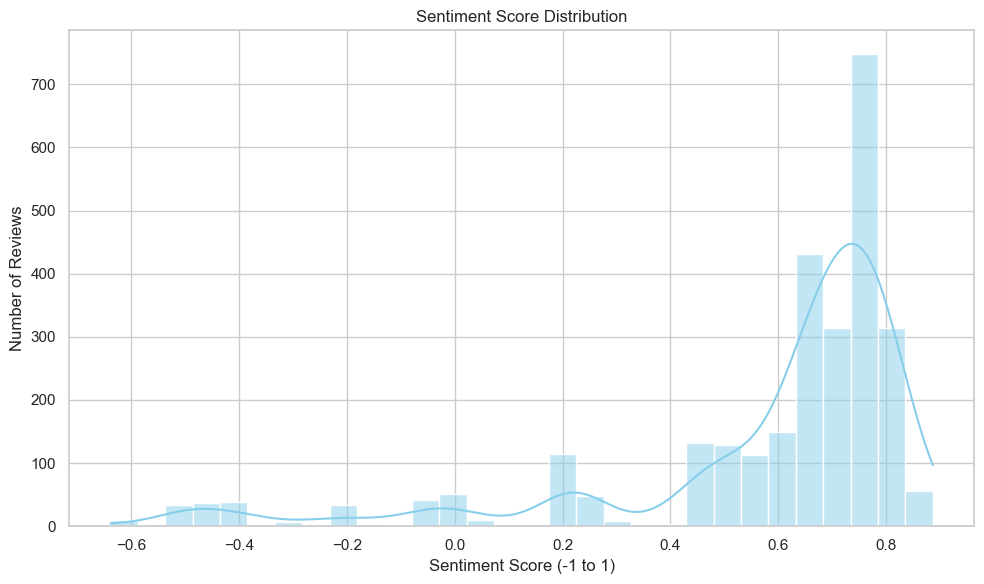

/var/folders/jv/xx87prbn6wscq58vdf6hct5h0000gn/T/ipykernel_3813/64966897.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


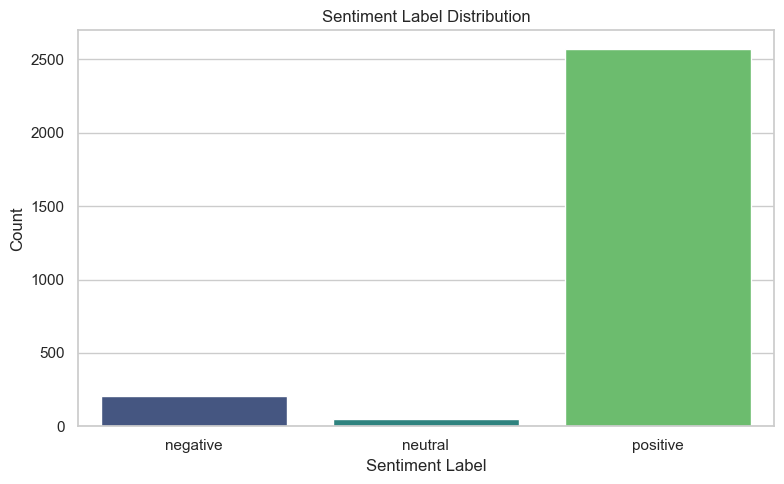

In [36]:
# -------------------------------
# 1. Load Data
# -------------------------------
viz_df = pd.read_csv("reviews_with_sentiment.csv")

# -------------------------------
# 2. Basic Setup
# -------------------------------
sns.set(style="whitegrid")

# -------------------------------
# 3. Sentiment Score Distribution (Histogram)
# -------------------------------
plt.figure(figsize=(10, 6))

sns.histplot(
    viz_df["sentiment_score"],
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score (-1 to 1)")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

# -------------------------------
# 4. Sentiment Label Distribution (Bar Chart)
# -------------------------------
plt.figure(figsize=(8, 5))


sns.countplot(
    data=viz_df,
    x="sentiment_label",
    palette="viridis",
    order=["negative", "neutral", "positive"]
)

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

LLM Prompt: with my "reviews_with_sentiment.csv" and columns "review_id,listing_id,user_id,review_text,sentiment_score,phrase_sentiments,sentiment_label" create a sentiment distribution chart

# User-User Collaborative Filtering Visualizations

In [37]:
# Recommendation spectrum: top, middle, and bottom ranked listings for a user.

def get_all_scores(user):
    """
    Score every unseen listing for a given user using predict_user_user().
    """
    # Listings this user has already rated
    seen = set(user_item.loc[user].dropna().index)

    rows = []
    for lid in user_item.columns:
        if lid in seen:
            continue

        pred, raw, support, conf = predict_user_user(user, lid)

        # Composite rank score
        rank = 0.7 * raw + 0.2 * conf + 0.1 * np.log1p(item_support.get(lid, 0))

        rows.append({
            "listing_id": lid,
            "predicted":  pred,
            "raw":        raw,
            "support":    support,
            "confidence": conf,
            "rank":       rank
        })

    result_df = pd.DataFrame(rows).sort_values("rank", ascending=False)
    return result_df.reset_index(drop=True)


def get_spectrum(user, n=10):
    """
    Split a user's recommendation scores into top, middle, and bottom tiers.
    """
    result_df = get_all_scores(user)

    top    = result_df.head(n)
    bottom = result_df.tail(n).sort_values("rank")

    mid_start = len(result_df) // 2 - n // 2
    middle    = result_df.iloc[mid_start: mid_start + n]

    return top, middle, bottom

Top rows: 8
Middle rows: 8
Bottom rows: 8


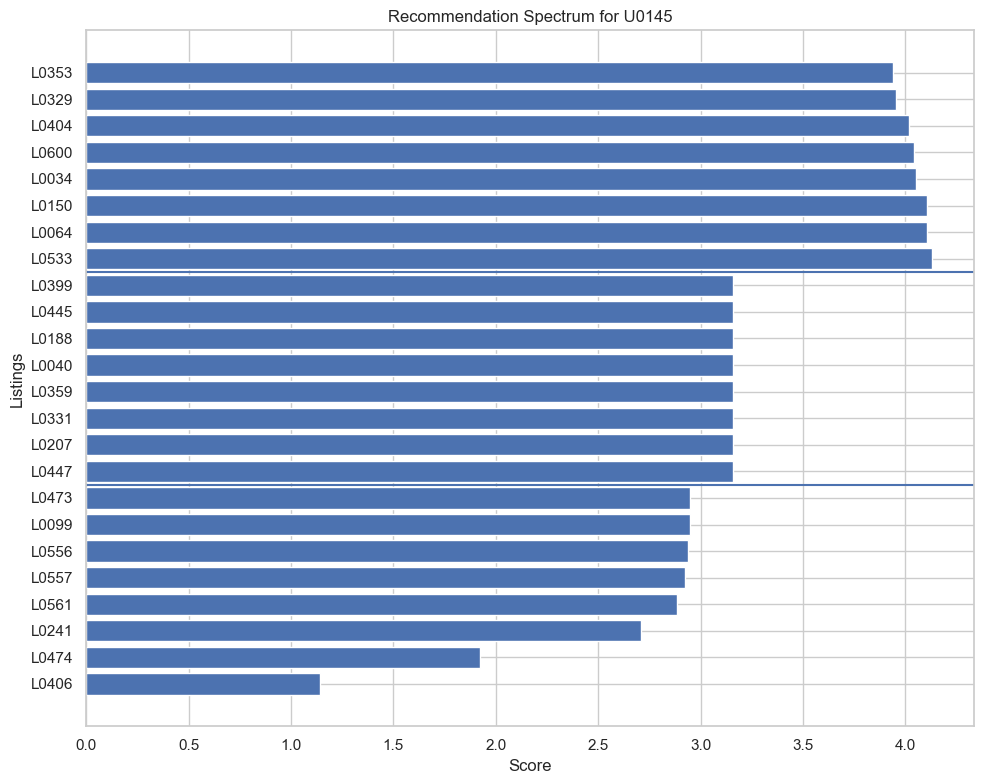

In [38]:
def plot_spectrum(user, n=8):
    """
    Plot a horizontal bar chart showing top, middle, and least recommended
    listings for a given user side by side.
    """
    top, middle, bottom = get_spectrum(user, n)

    top    = top.copy()
    middle = middle.copy()
    bottom = bottom.copy()

    print("Top rows:",    len(top))
    print("Middle rows:", len(middle))
    print("Bottom rows:", len(bottom))

    if top.empty and middle.empty and bottom.empty:
        print("No data to plot.")
        return

    # Tag each tier
    top["group"]    = "Top"
    middle["group"] = "Middle"
    bottom["group"] = "Least"

    #  chart reads low-to-high
    plot_df = pd.concat([bottom, middle, top], ignore_index=True)

    if plot_df.empty:
        print("Combined dataframe is empty.")
        return

    plot_df["label"] = plot_df["listing_id"].astype(str)

    plt.figure(figsize=(10, 8))
    plt.barh(plot_df["label"], plot_df["rank"])

    plt.title(f"Recommendation Spectrum for {user}")
    plt.xlabel("Score")
    plt.ylabel("Listings")

    n_bottom = len(bottom)
    n_middle = len(middle)
    if n_bottom > 0:
        plt.axhline(n_bottom - 0.5)
    if n_middle > 0:
        plt.axhline(n_bottom + n_middle - 0.5)

    plt.tight_layout()
    plt.show()


# Run on the first user
sample_user = user_booking["user_id"].iloc[0]
plot_spectrum(sample_user)

LLM prompt used: Act like a professional data scientist. I have already built a user-user collaborative filtering model in Python that produces ranked recommendation scores for Airbnb listings by user. Please create a Python visualization that shows the top recommended, middle-ranked, and least recommended listings for a sample user in a clear horizontal bar chart for presentation purposes.

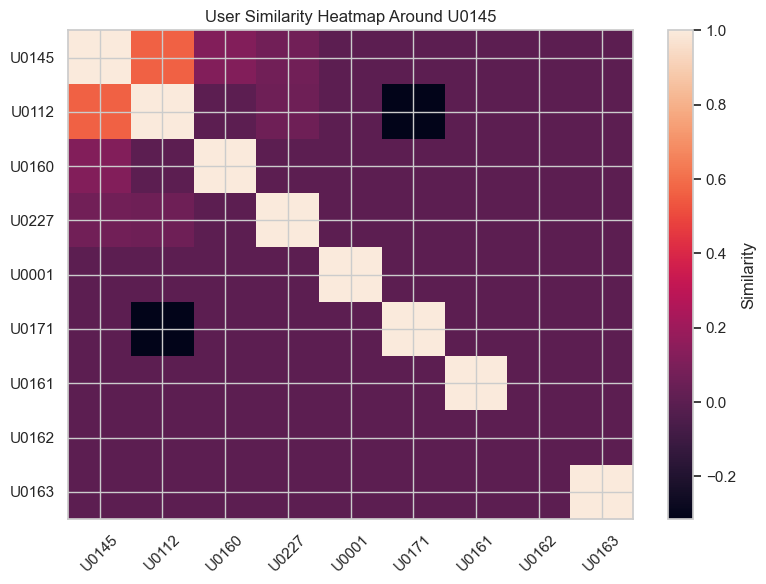

In [39]:
def plot_user_similarity_heatmap(target_user, top_n=10):
    """
    Plot a heatmap of cosine similarity scores between the target user
    and their most similar neighbors.
    """
    if target_user not in user_sim.index:
        print("User not found.")
        return

    # Get top similar users including the target user themselves
    sims           = user_sim.loc[target_user].sort_values(ascending=False).head(top_n + 1)
    selected_users = sims.index.tolist()

    heatmap_df = user_sim.loc[selected_users, selected_users]

    plt.figure(figsize=(8, 6))
    plt.imshow(heatmap_df, aspect='auto')
    plt.colorbar(label="Similarity")

    plt.xticks(range(len(selected_users)), selected_users, rotation=45)
    plt.yticks(range(len(selected_users)), selected_users)

    plt.title(f"User Similarity Heatmap Around {target_user}")
    plt.tight_layout()
    plt.show()


sample_user = user_booking["user_id"].iloc[0]
plot_user_similarity_heatmap(sample_user, top_n=8)

LLM prompt used: Act like a professional data scientist. I have already computed a user-user cosine similarity matrix for an Airbnb recommendation model in Python. Please create a Python heatmap visualization showing the target user and their most similar neighboring users so that I can clearly explain how collaborative filtering is using similarity to generate recommendations.